# Federated Learning with Flower

## Introduction

Flower (```flwr```) is a framework used to build Federated Learning systems. It was created with the mind of customizability, extendability, adapting with multiple machine learning framework, but easily understandable to provide desirable maintainability for its users.

To proceed, we install the necessary modules via pip, including flower itself, the machine learning framework we will be using and others:

In [16]:
!pip install -q 'flwr[simulation]' 'flwr_datasets[vision]' torch torchvision matplotlib numpy

Then, we import the modules:

In [17]:
from collections import OrderedDict
from typing import List, Tuple, Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from datasets.utils.logging import disable_progress_bar
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10

import flwr as fl
from flwr.common import Metrics
from flwr_datasets import FederatedDataset

To see where this machine learning is running on:

In [18]:
DEVICE = torch.device("cuda")  # If GPU available, use "cuda?, if not available or any errors, change to "cpu" to use CPU
print (f"Train on {DEVICE} using Pytorch {torch.__version__} and Flower {fl.__version__}")
disable_progress_bar();

Train on cuda using Pytorch 2.1.0+cu121 and Flower 1.7.0


## Loading Data

In this notebook, we are going to train an image classifiers on a dataset CIFAR-10, the model after training should be able to classify objects in the image, such as airplane, dogs or trucks.

In real-life scenario, a huge dataset is always to gluing outcome of multiple smaller datasets from different entities. This is also the case from Federated Learning, there is no transfer on data, there is no chance of them to sit in a large database. Of course they could also play the role of different collaborators, trying to utilise machine learning techniques but having solid data security concerns or regulations, making them unwilling to share the data.

Now we will import the data and slice it:

In [19]:
NUM_CLIENTS = 10
BATCH_SIZE = 32

def load_datasets():
  dataset_federated = FederatedDataset(
      dataset="cifar10",
      partitioners={"train": NUM_CLIENTS}
      )

  def apply_transforms(batch):
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
        ]
    )
    batch["img"] = [transform(img) for img in batch["img"]]
    return batch

  trainloaders = []
  valloaders = []
  for partition_id in range(NUM_CLIENTS):
    partition = dataset_federated.load_partition(partition_id, "train")
    partition = partition.with_transform(apply_transforms)
    partition = partition.train_test_split(train_size=0.8)
    trainloaders.append(DataLoader(partition["train"], batch_size=BATCH_SIZE))
    valloaders.append(DataLoader(partition["test"], batch_size=BATCH_SIZE))
  testset = dataset_federated.load_full("test").with_transform(apply_transforms)
  testloader = DataLoader(testset, batch_size=BATCH_SIZE)
  return trainloaders, valloaders, testloader

trainloaders, valloaders, testloader = load_datasets()

What the snippet above did is to create 10 training sets and 10 validation sets, respectively ```trainloaders``` and ```valloaders```. representing 10 different organisatiosn let's say. Each of this "organisation" will pair 4500 training examples from the "trainloader" and 500 validation examples from the "valloader".

There is also a complete set of data as ```testloader```.

Now, we inspect the data see if things are getting in:

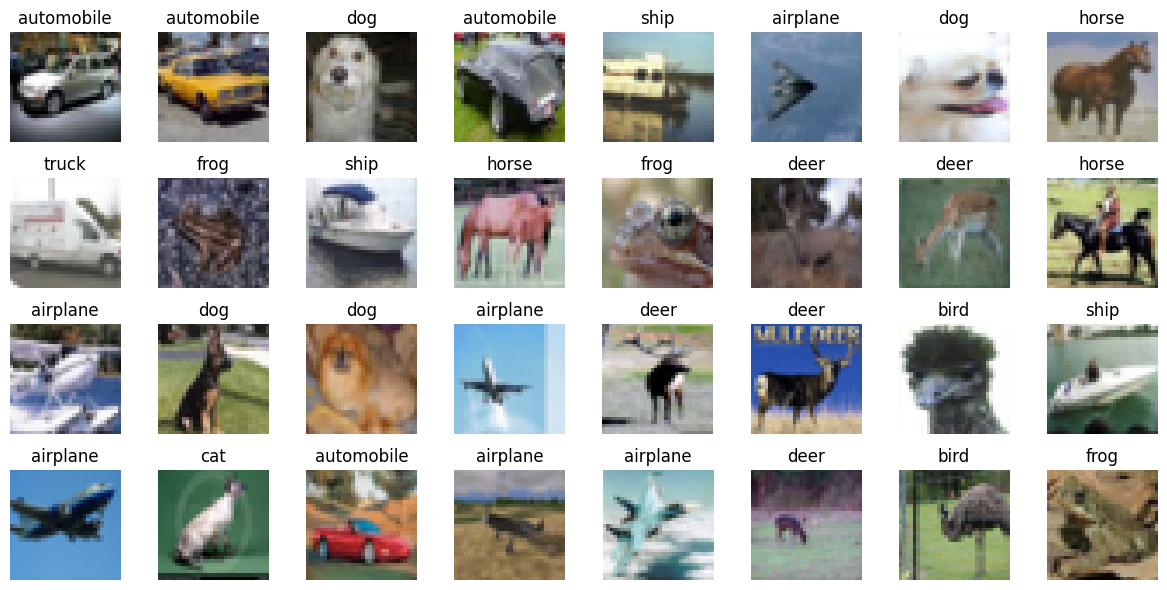

In [20]:
batch = next(iter(trainloaders[0]))
images, labels = batch["img"], batch["label"]

# Now we change this to a numpy array, matplotlib will require it as (h, w, 3)
images = images.permute(0,2,3,1).numpy()

images = images / 2 + 0.5

# Create Visual

fig, axs = plt.subplots(4,8,figsize=(12,6))

for i,ax in enumerate(axs.flat):
  ax.imshow(images[i])
  ax.set_title(trainloaders[0].dataset.features["label"].int2str([labels[i]])[0])
  ax.axis("off")
fig.tight_layout()
plt.show()

## Centralised Machine Learning

So first we will just do this with PyTorch simply, just like the old application of centralised machine learing.

### Define the Model

We use a Convolutional Neural Network, also known as CNN:

In [21]:
class Net(nn.Module):
  def __init__(self) -> None:
    super(Net, self).__init__()
    self.conv1 = nn.Conv2d(3,6,5)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(6,16,5)
    self.fc1 = nn.Linear(16 * 5 * 5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.view(-1, 16 * 5 * 5)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

# train() and test()

def train(net, trainloader, epochs: int, verbose=False):
  criterion = torch.nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(net.parameters())
  net.train()
  for epoch in range(epochs):
    correct,total,epoch_loss = 0, 0, 0.0
    for batch in trainloader:
      images, labels = batch["img"].to(DEVICE), batch["label"].to(DEVICE)
      optimizer.zero_grad()
      outputs = net(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      epoch_loss += loss
      total += labels.size(0)
      correct += (torch.max(outputs.data, 1)[1] == labels).sum().item()
    epoch_loss /= len(trainloader.dataset)
    epoch_acc = correct / total
    if verbose:
      print(f"Epoch {epoch+1}: train_loss {loss} accuracy {accuracy}")

def test(net, testloader):
  criterion = torch.nn.CrossEntropyLoss()
  correct, total, loss = 0, 0, 0.0
  net.eval()
  with torch.no_grad():
    for batch in testloader:
      images, labels = batch["img"].to(DEVICE), batch["label"].to(DEVICE)
      outputs = net(images)
      loss += criterion(outputs, labels).item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  loss /= len(testloader.dataset)
  accuracy = correct / total
  return loss, accuracy

### Train the Model

Now we train the model, but this time we only use one organisation ```trainloaders[0]``` and ```valloaders[0]```.

In [22]:
trainloader = trainloaders[0]
valloader = valloaders[0]
net = Net().to(DEVICE)

for epoch in range(5):
  train(net,trainloader, 1)
  loss, accuracy = test(net, valloader)
  print(f"Epoch {epoch+1}: Validation Loss: {loss}, Accuracy: {accuracy}")

loss, accuracy = test(net, testloader)
print(f"Final test set performance:\n\tLoss: {loss}\n\tAccurary: {accuracy}")

Epoch 1: Validation Loss: 0.06228524971008301, Accuracy: 0.25
Epoch 2: Validation Loss: 0.05637870252132416, Accuracy: 0.313
Epoch 3: Validation Loss: 0.054221086621284484, Accuracy: 0.344
Epoch 4: Validation Loss: 0.0528446352481842, Accuracy: 0.368
Epoch 5: Validation Loss: 0.05178504586219788, Accuracy: 0.388
Final test set performance:
	Loss: 0.05029713881015778
	Accurary: 0.4017


Now you just tried your first machine learning pipeline. Congrats! The accuracy obviously is not all time high, but it's fine.

## Federated Learning with Flower

In the learning before, we just used one "organisation" (```trainloaders[0]``` and ```valloaders[0]```). Now we will actually deploy Federated Learning, making this machine learning actually go accross multiple "organisations".

### Update Model Parameters

In Federated Learning, the global server firstly sends the Global Model's Parameters to each client, then the client will update the local model with the parameters by training the model with its local data. Then the updated model with new parameters will be sent back to the server, or actually the gradients back to the global server instead of full model parameters.

To achieve this, we need to helper functions ```set_parameters()``` and ```get_parameters()``` for the client to use. The parameters will be retrieved from the tensors as dicts, then converted into a list of numpy ndarrays, which Flower can serialise and deseriliase.

In [23]:
def set_parameters(net, parameters: List[np.ndarray]) -> None:
  params_dict = zip(net.state_dict().keys(), parameters)
  state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
  net.load_state_dict(state_dict, strict=True)

def get_parameters(net) -> List[np.ndarray]:
  return [val.cpu().numpy() for _, val in net.state_dict().items()]

### Implement Flower Client

A Federated Learning Framework consists a shared global server for model aggregation and update and multiple clients for model training. In Flower, how you create each of those clients is to implement subclass of built-in classes in Flower ```flwr.client.Client()``` or ```flwr.client.NumPyClient```, and this subclass implement 3 key functions:

* ```get_parameters```: Return current Local Model's Parameters.
* ```fit```:
  * Receive Global Model Parameters from the server.
  * Train the Model Parameters with local data.
  * Return the Updated Local Parameters to the server.
* ```evaluate```:
  * Receive Update Global Model Parameters from the server.
  * Evaluate the Model Parameters with local data.
  * Return the evaluation result to the server.

We can just use our functions defined previously when we are demostrating PyTorch with centralised machine learning:

In [24]:
class FlowerClient(fl.client.NumPyClient):
  def __init__(self, net, trainloader, valloader):
    self.net = net
    self.trainloader = trainloader
    self.valloader = valloader

  def get_parameters(self, config):
    return get_parameters(self.net)

  def fit(self, parameters, config):
    set_parameters(self.net, parameters)
    train(self.net, self.trainloader, epochs=1)
    return get_parameters(self.net), len(self.trainloader), {}

  def evaluate(self, parameters, config):
    set_parameters(self.net, parameters)
    loss, accuracy = test(self.net, self.valloader)
    return float(loss), len(self.valloader), {"accuracy": float(accuracy)}

From now then on, each client in our Federated Learning Framework is an instance of this class.

### Use Virtual Client Engine

If we have 10 clients, normally it would mean that we have 10 devices with their own hardwares to run the client-side jobs. However, here we are trying to simulate this in one device, this could be resource-consuming as all clients are sharing the same hardware with each other on the same machine.

To avoid this resource blackhole, we can utilise Flower's special simulation capacities to create clients on demand: they will only be created when necessary and they will be discarded after use when no longer needed without any local state kept.

Here, ```client_fn(cid: str)``` is the function used here that whenever a client needs to be created, Flower will call this function and whenever it needs a instance of one particular client to use ```fit()``` and ```evaluate()```. The identification is done by client ID.

In [25]:
def client_fn(cid: str) -> FlowerClient:
  return FlowerClient(
    Net().to(DEVICE),
    trainloaders[int(cid)],
    valloaders[int(cid)]
  ).to_client()

### Accuracy

If we just go set the train now, we won't be able to find the accuracy. Flower can automatically aggregate losses from individual clients, but not the same for metrics in the generic metrics dictionary \(the one with the accuracy key\). The metrics dictionaries can contain very different kinds of metrics and even k/v pairs that are not metrics at all. This leads to the framework has no idea how to handle these automatically.

As the users we need to tell the framework to handle/aggregate these custom metrics, we do this by passing the metric aggregatin fuctions into the strategy as parameter, possibly ```fit_metrics_aggregation_fn``` and ```evaluate_metrics_aggregation_fn```, the strategy will then call the function whenever it receives fit or evaluate metrics from clients.

In [26]:
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
  # Accuracy of Each Client * Number of Examples
  accus = [num_examples * m["accuracy"] for num_examples, m in metrics]
  examples = [num_examples for num_examples, _ in metrics]

  return {"accuracy": sum(accus) / sum(examples)}

### De Train

Now we have everything prepared, it's time to train, with ```flwr.simulation.start_simulation()```.

Just like before, this function accepts numerous variables, including the ```client_fn``` to create ```FlowerClient``` instances, number of clients, number of rounds, and the strategy, which is the Federated Learning Algorithm/Approach we are using here - Federated Averaging, here it encapsulates the built-in  strategies ```fl.server.strategy.FedAvg```, where of course, you can pass some parameters in to customize your strategy a bit:

In [27]:
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0, # Sample 100% of the clients for training
    fraction_evaluate=0.5, # Sample 50% of the clients for evaluation
    min_fit_clients=10, # Never Sample less than 10 clients
    min_evaluate_clients=5, # Never sample less than 5 clients for evaluation
    min_available_clients=10, # Wait until all 10 clients are available
    # Pass the metric aggregation function
    evaluate_metrics_aggregation_fn=weighted_average,
)

client_resources = {"num_cpus": 1, "num_gpus": 0.0}
if DEVICE.type == "cuda":
  client_resources = {"num_cpus": 1, "num_gpus": 1.0}

fl.simulation.start_simulation(
    client_fn=client_fn, # How to call Clients?
    num_clients=NUM_CLIENTS, # How many Clients should be there?
    config=fl.server.ServerConfig(num_rounds=5), # How many rounds?
    strategy=strategy, # How to use these clients?
    client_resources=client_resources, # What hardware are we on?
)

INFO flwr 2024-03-05 09:08:38,319 | app.py:178 | Starting Flower simulation, config: ServerConfig(num_rounds=5, round_timeout=None)
INFO:flwr:Starting Flower simulation, config: ServerConfig(num_rounds=5, round_timeout=None)
2024-03-05 09:08:42,663	INFO worker.py:1621 -- Started a local Ray instance.
INFO flwr 2024-03-05 09:08:45,812 | app.py:213 | Flower VCE: Ray initialized with resources: {'memory': 7848451278.0, 'object_store_memory': 3924225638.0, 'node:__internal_head__': 1.0, 'CPU': 2.0, 'node:172.28.0.12': 1.0, 'GPU': 1.0}
INFO:flwr:Flower VCE: Ray initialized with resources: {'memory': 7848451278.0, 'object_store_memory': 3924225638.0, 'node:__internal_head__': 1.0, 'CPU': 2.0, 'node:172.28.0.12': 1.0, 'GPU': 1.0}
INFO flwr 2024-03-05 09:08:45,815 | app.py:219 | Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html
INFO:flwr:Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html


History (loss, distributed):
	round 1: 0.06367601399421692
	round 2: 0.05688663289546967
	round 3: 0.05331625432968139
	round 4: 0.050180365872383115
	round 5: 0.04928694322109223
History (metrics, distributed, evaluate):
{'accuracy': [(1, 0.3008), (2, 0.353), (3, 0.3792), (4, 0.4316), (5, 0.43360000000000004)]}

Congrats! You have just finished the most initial part of learning Flower.

Now, We are focusing on Strategy:

# Flower Strategies

For this chapter, we use the CIFAR-10 training and test set, and we participate them into smaller datasets, to do this, ```load_datasets()``` is welcoming a new argument: ```num_clients: int```:

In [ ]:
NUM_CLIENTS = 10 # Just to be sure

def load_datasets(num_clients: int):
  transform = transforms.Compose(
      [transforms.ToTensor(), transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))]
  )
  trainset = CIFAR10("./dataset", train=True, download=True, transform=transform)
  testset = CIFAR10("./dataset", train=False, download=False transform=transform)

## Strategy Customization

### Server-side Parameter Initialisation

Flower, by default, initialise the Global Model by asking one random client for the initial parameters, though in real life we will want to control during parameter initialisation. Flower allows you to pass initial parameters to the ```strategy```:

In [28]:
# Retrieve Parameters
params = get_parameters(Net())

# Apply Parameters
strategy_custom_1 = fl.server.strategy.FedAvg(
  fraction_fit=0.3,
  fraction_evaluate=0.3,
  min_fit_clients=3,
  min_evaluate_clients=NUM_CLIENTS,
  initial_parameters=fl.common.ndarrays_to_parameters(params),
)

# Prepare Resource
client_resources = {"num_cpus": 1, "num_gpus": 0}
if DEVICE.type == "cuda":
  client_resources = {"num_cpus": 1, "num_gpus": 1}

# Start Simulation
fl.simulation.start_simulation(
  client_fn=client_fn, num_clients=NUM_CLIENTS, config=fl.server.ServerConfig(num_rounds=3), client_resources=client_resources, strategy=strategy_custom_1,
)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
WARNING flwr 2024-03-05 09:10:40,977 | fedavg.py:118 | 
Setting `min_available_clients` lower than `min_fit_clients` or
`min_evaluate_clients` can cause the server to fail when there are too few clients
connected to the server. `min_available_clients` must be set to a value larger
than or equal to the values of `min_fit_clients` and `min_evaluate_clients`.

Setting `min_available_clients` lower than `min_fit_clients` or
`min_evaluate_clients` can cause the server to fail when there are too few clients
connected to the server. `min_available_clients` must be set to a value larger
than or equal to the values of `min_fit_clients` and `min_e

History (loss, distributed):
	round 1: 0.062460343539714816
	round 2: 0.05573261518478394
	round 3: 0.05276158475875855

By using ```initial_parameters``` parameter in ```FedAvg``` strategy will stop Flower from asking a client for initial parameters. You will notice during this simulation ```FlowerClient.get_parameters()``` is never used.

Now, instead of ```FedAvg```, we try another Federated Learning Algorithm/Approach ```FedAdagrad```:

In [29]:
# FedAdam Strategy
strategy_custom_2 = fl.server.strategy.FedAdagrad(
  fraction_fit=0.3,
  fraction_evaluate=0.3,
  min_fit_clients=3,
  min_evaluate_clients=3,
  min_available_clients=NUM_CLIENTS,
  initial_parameters=fl.common.ndarrays_to_parameters(get_parameters(Net())),
)

# Simulation
fl.simulation.start_simulation(
  client_fn=client_fn, num_clients=NUM_CLIENTS, config=fl.server.ServerConfig(num_rounds=3), client_resources=client_resources, strategy=strategy_custom_2,
)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
INFO flwr 2024-03-05 09:11:28,179 | app.py:178 | Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
INFO:flwr:Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
2024-03-05 09:11:32,850	INFO worker.py:1621 -- Started a local Ray instance.
INFO flwr 2024-03-05 09:11:35,036 | app.py:213 | Flower VCE: Ray initialized with resources: {'GPU': 1.0, 'node:172.28.0.12': 1.0, 'memory': 7847406798.0, 'object_store_memory': 3923703398.0, 'CPU': 2.0, 'node:__internal_head__': 1.0}
INFO:flwr:Flower VCE: Ray initialized with resources: {'GPU': 1.0, 'node:172.28.0.12': 1.0, 'memory': 784740

History (loss, distributed):
	round 1: 4.1357688649495445
	round 2: 0.9354650141398112
	round 3: 0.15747697575887043

## Server-side Parameter Evaluation

The aggregated model can be evaluated via Parameter evaluation, it has server-side evaluation and client-side evaluation, and Flower supports both:

* Centralised Evaluation, or Server-side Evaluation is what centralised machine does as well. If there is a server-side dataset for evaluation purpose \(just like ```testloader```\), then it can evaluate the newly aggregated model after each round of training without the needs to send the model to clients.

* Federated Evaluation, or Client-side Evaluation, does not require a centralised dataset so we can evaluate with huge amount of data, but that's how life normally is, Federated Evaluation is actually more required in real life as we want to get representative evaluation results. However, the cost is our evaluation dataset can change over thru rounds as clients may not be available, data are held by clients, and they can change as well. The evaluation result can be not stable and fluctuate a lot.

What we did before is actually client-side evaluation, for server-side evaluation it is something like this:

In [31]:
 # Called after every round
def evaluate_server_side(
  server_round: int,
  parameters: fl.common.NDArrays,
  config: {str, fl.common.Scalar},
) -> Tuple[float, dict[str, fl.common.Scalar]]:
  net = Net().to(DEVICE)
  valloader = valloaders[0]
  set_parameters(net, parameters)
  loss, accuracy = test (net, valloader)
  print(f"Server-side evaluation loss {loss} / accuracy {accuracy}")
  return loss, {"accuracy": accuracy}

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [32]:
strategy_custom_3 = fl.server.strategy.FedAvg(
  fraction_fit=0.3,
  fraction_evaluate=0.3,
  min_fit_clients=3,
  min_evaluate_clients=3,
  min_available_clients=NUM_CLIENTS,
  initial_parameters=fl.common.ndarrays_to_parameters(get_parameters(Net())),
  evaluate_fn=evaluate_server_side,
)

fl.simulation.start_simulation(
  client_fn=client_fn, num_clients=NUM_CLIENTS, config=fl.server.ServerConfig(num_rounds=3), client_resources=client_resources, strategy=strategy_custom_3,
)

INFO flwr 2024-03-05 09:16:13,344 | app.py:178 | Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
INFO:flwr:Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
2024-03-05 09:16:18,723	INFO worker.py:1621 -- Started a local Ray instance.
INFO flwr 2024-03-05 09:16:20,582 | app.py:213 | Flower VCE: Ray initialized with resources: {'object_store_memory': 3923388825.0, 'node:__internal_head__': 1.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0, 'CPU': 2.0, 'memory': 7846777652.0}
INFO:flwr:Flower VCE: Ray initialized with resources: {'object_store_memory': 3923388825.0, 'node:__internal_head__': 1.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0, 'CPU': 2.0, 'memory': 7846777652.0}
INFO flwr 2024-03-05 09:16:20,591 | app.py:219 | Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html
INFO:flwr:Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html


Server-side evaluation loss 0.07374631333351135 / accuracy 0.101


(pid=15851) 2024-03-05 09:16:22.214776: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=15851) 2024-03-05 09:16:22.214828: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=15851) 2024-03-05 09:16:22.216093: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=15851) 2024-03-05 09:16:23.279919: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
DEBUG flwr 2024-03-05 09:16:33,708 | server.py:236 | fit_round 1 received 3 results and 0 failures
DEBUG:flwr:fit_round 1 received 3 results and 0 failures
WARNING flwr 2024-03-05 09:16:33,718 

Server-side evaluation loss 0.06370550775527954 / accuracy 0.307


DEBUG flwr 2024-03-05 09:16:35,822 | server.py:187 | evaluate_round 1 received 3 results and 0 failures
DEBUG:flwr:evaluate_round 1 received 3 results and 0 failures
WARNING flwr 2024-03-05 09:16:35,826 | fedavg.py:281 | No evaluate_metrics_aggregation_fn provided
DEBUG flwr 2024-03-05 09:16:35,829 | server.py:222 | fit_round 2: strategy sampled 3 clients (out of 10)
DEBUG:flwr:fit_round 2: strategy sampled 3 clients (out of 10)
DEBUG flwr 2024-03-05 09:16:41,815 | server.py:236 | fit_round 2 received 3 results and 0 failures
DEBUG:flwr:fit_round 2 received 3 results and 0 failures
INFO flwr 2024-03-05 09:16:42,158 | server.py:125 | fit progress: (2, 0.05600057482719421, {'accuracy': 0.358}, 20.757939694000015)
INFO:flwr:fit progress: (2, 0.05600057482719421, {'accuracy': 0.358}, 20.757939694000015)
DEBUG flwr 2024-03-05 09:16:42,161 | server.py:173 | evaluate_round 2: strategy sampled 3 clients (out of 10)
DEBUG:flwr:evaluate_round 2: strategy sampled 3 clients (out of 10)


Server-side evaluation loss 0.05600057482719421 / accuracy 0.358


DEBUG flwr 2024-03-05 09:16:43,574 | server.py:187 | evaluate_round 2 received 3 results and 0 failures
DEBUG:flwr:evaluate_round 2 received 3 results and 0 failures
DEBUG flwr 2024-03-05 09:16:43,578 | server.py:222 | fit_round 3: strategy sampled 3 clients (out of 10)
DEBUG:flwr:fit_round 3: strategy sampled 3 clients (out of 10)
DEBUG flwr 2024-03-05 09:16:48,536 | server.py:236 | fit_round 3 received 3 results and 0 failures
DEBUG:flwr:fit_round 3 received 3 results and 0 failures
INFO flwr 2024-03-05 09:16:48,884 | server.py:125 | fit progress: (3, 0.051668845057487485, {'accuracy': 0.406}, 27.48416535899969)
INFO:flwr:fit progress: (3, 0.051668845057487485, {'accuracy': 0.406}, 27.48416535899969)
DEBUG flwr 2024-03-05 09:16:48,888 | server.py:173 | evaluate_round 3: strategy sampled 3 clients (out of 10)
DEBUG:flwr:evaluate_round 3: strategy sampled 3 clients (out of 10)


Server-side evaluation loss 0.051668845057487485 / accuracy 0.406


DEBUG flwr 2024-03-05 09:16:50,334 | server.py:187 | evaluate_round 3 received 3 results and 0 failures
DEBUG:flwr:evaluate_round 3 received 3 results and 0 failures
INFO flwr 2024-03-05 09:16:50,338 | server.py:153 | FL finished in 28.938137578999886
INFO:flwr:FL finished in 28.938137578999886
INFO flwr 2024-03-05 09:16:50,340 | app.py:226 | app_fit: losses_distributed [(1, 0.06407064934571584), (2, 0.05577068463961283), (3, 0.053288194696108494)]
INFO:flwr:app_fit: losses_distributed [(1, 0.06407064934571584), (2, 0.05577068463961283), (3, 0.053288194696108494)]
INFO flwr 2024-03-05 09:16:50,341 | app.py:227 | app_fit: metrics_distributed_fit {}
INFO:flwr:app_fit: metrics_distributed_fit {}
INFO flwr 2024-03-05 09:16:50,343 | app.py:228 | app_fit: metrics_distributed {}
INFO:flwr:app_fit: metrics_distributed {}
INFO flwr 2024-03-05 09:16:50,345 | app.py:229 | app_fit: losses_centralized [(0, 0.07374631333351135), (1, 0.06370550775527954), (2, 0.05600057482719421), (3, 0.0516688450574

History (loss, distributed):
	round 1: 0.06407064934571584
	round 2: 0.05577068463961283
	round 3: 0.053288194696108494
History (loss, centralized):
	round 0: 0.07374631333351135
	round 1: 0.06370550775527954
	round 2: 0.05600057482719421
	round 3: 0.051668845057487485
History (metrics, centralized):
{'accuracy': [(0, 0.101), (1, 0.307), (2, 0.358), (3, 0.406)]}

## Passing Arbitrary Values between clients and server

In some situations, we want to configure client-side training/evaluation from the server side, such as server may ask clients to train certain amount of epochs. Flower manages this with dictionary thru ```config``` parameter and this applies for both ```fit()``` and ```evaluate()```.

In [33]:
# IN this client, it reads server_round and local epochs
# to improve better loggin and configure the number of local training epochs

class FlowerClient_arbi(fl.client.NumPyClient):
  def __init__(self, cid, net, trainloader, valloader):
    self.cid = cid
    self.net = net
    self.trainloader = trainloader
    self.valloader = valloader

  def get_parameters(self, config):
    print(f"[Client {self.cid}] Starting to Gather Parameters")
    return get_parameters(self.net)

  def fit(self, parameters, config):
    # Substitute the value from the config dictionary
    server_round = config["server_round"]
    local_epochs = config["local_epochs"]

    # Apply to config
    print(f"[Client {self.cid}] Starting fit round {server_round}, config: {config}")
    set_parameters(self.net, parameters)
    train(self.net, self.trainloader, epochs=local_epochs)
    return get_parameters(self.net), len(self.trainloader), {}

  def evaluate(self, parameters, config):
    print(f"[Client {self.cid}] Starting evaluation, config: {config}")
    set_parameters(self.net, parameters)
    loss, accuracy = test(self.net, self.valloader)
    return float(loss), len(self.valloader), {"accuracy": float(accuracy)}

def client_fn_arbi(cid) -> FlowerClient:
  net = Net().to(DEVICE)
  trainloader = trainloaders[int(cid)]
  valloader = valloaders[int(cid)]
  return FlowerClient_arbi(cid, net, trainloader, valloader)


How Flower pass these configs from server to clients is by using  Flower Strategy parameters to pass the function, which will run the function every round:

In [34]:
def fit_config(server_round: int):
  return {
    "server_round": server_round,
    "local_epochs": 1 if server_round < 2 else 2,
  }

strategy_custom_4 = fl.server.strategy.FedAvg(
  fraction_fit=0.3,
  fraction_evaluate=0.3,
  min_fit_clients=3,
  min_evaluate_clients=3,
  min_available_clients=NUM_CLIENTS,
  initial_parameters=fl.common.ndarrays_to_parameters(get_parameters(Net())),
  evaluate_fn=evaluate_server_side,
  on_fit_config_fn=fit_config,
)

fl.simulation.start_simulation(
  client_fn=client_fn_arbi,
  num_clients=NUM_CLIENTS,
  config=fl.server.ServerConfig(num_rounds=3),
  strategy=strategy_custom_4,
  client_resources=client_resources
)

INFO flwr 2024-03-05 09:17:02,666 | app.py:178 | Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
INFO:flwr:Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
2024-03-05 09:17:07,248	INFO worker.py:1621 -- Started a local Ray instance.
INFO flwr 2024-03-05 09:17:09,362 | app.py:213 | Flower VCE: Ray initialized with resources: {'memory': 7845853595.0, 'object_store_memory': 3922926796.0, 'node:__internal_head__': 1.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0, 'CPU': 2.0}
INFO:flwr:Flower VCE: Ray initialized with resources: {'memory': 7845853595.0, 'object_store_memory': 3922926796.0, 'node:__internal_head__': 1.0, 'GPU': 1.0, 'node:172.28.0.12': 1.0, 'CPU': 2.0}
INFO flwr 2024-03-05 09:17:09,366 | app.py:219 | Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html
INFO:flwr:Optimize your simulation with Flower VCE: https://flower.dev/docs/framework/how-to-run-simulations.html


Server-side evaluation loss 0.07361310935020447 / accuracy 0.11


(pid=16250) 2024-03-05 09:17:10.954420: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=16250) 2024-03-05 09:17:10.954479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=16250) 2024-03-05 09:17:10.955695: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=16250) 2024-03-05 09:17:12.015045: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
(DefaultActor pid=16250) /usr/local/lib/python3.10/dist-packages/flwr/simulation/ray_transport/ray_actor.py:72: DeprecationWarning:  Ensure your client is of type `flwr.client.Client`. Please c

(DefaultActor pid=16250) [Client 3] Starting fit round 1, config: {'server_round': 1, 'local_epochs': 1}
(DefaultActor pid=16250) [Client 0] Starting fit round 1, config: {'server_round': 1, 'local_epochs': 1}
(DefaultActor pid=16250) [Client 8] Starting fit round 1, config: {'server_round': 1, 'local_epochs': 1}


DEBUG flwr 2024-03-05 09:17:22,625 | server.py:236 | fit_round 1 received 3 results and 0 failures
DEBUG:flwr:fit_round 1 received 3 results and 0 failures
WARNING flwr 2024-03-05 09:17:22,634 | fedavg.py:250 | No fit_metrics_aggregation_fn provided
INFO flwr 2024-03-05 09:17:22,957 | server.py:125 | fit progress: (1, 0.06468407225608826, {'accuracy': 0.26}, 12.742354154999703)
INFO:flwr:fit progress: (1, 0.06468407225608826, {'accuracy': 0.26}, 12.742354154999703)
DEBUG flwr 2024-03-05 09:17:22,961 | server.py:173 | evaluate_round 1: strategy sampled 3 clients (out of 10)
DEBUG:flwr:evaluate_round 1: strategy sampled 3 clients (out of 10)


...

(DefaultActor pid=16250) [Client 6] Starting fit round 3, config: {'server_round': 3, 'local_epochs': 2}
(DefaultActor pid=16250) [Client 8] Starting fit round 3, config: {'server_round': 3, 'local_epochs': 2}
(DefaultActor pid=16250) [Client 7] Starting fit round 3, config: {'server_round': 3, 'local_epochs': 2}


DEBUG flwr 2024-03-05 09:17:47,959 | server.py:236 | fit_round 3 received 3 results and 0 failures
DEBUG:flwr:fit_round 3 received 3 results and 0 failures
INFO flwr 2024-03-05 09:17:48,311 | server.py:125 | fit progress: (3, 0.05041838121414185, {'accuracy': 0.425}, 38.09638797499974)
INFO:flwr:fit progress: (3, 0.05041838121414185, {'accuracy': 0.425}, 38.09638797499974)
DEBUG flwr 2024-03-05 09:17:48,316 | server.py:173 | evaluate_round 3: strategy sampled 3 clients (out of 10)
DEBUG:flwr:evaluate_round 3: strategy sampled 3 clients (out of 10)


Server-side evaluation loss 0.05041838121414185 / accuracy 0.425
(DefaultActor pid=16250) [Client 7] Starting evaluation, config: {}
(DefaultActor pid=16250) [Client 8] Starting evaluation, config: {}
(DefaultActor pid=16250) [Client 2] Starting evaluation, config: {}


DEBUG flwr 2024-03-05 09:17:49,761 | server.py:187 | evaluate_round 3 received 3 results and 0 failures
DEBUG:flwr:evaluate_round 3 received 3 results and 0 failures
INFO flwr 2024-03-05 09:17:49,765 | server.py:153 | FL finished in 39.54994835299976
INFO:flwr:FL finished in 39.54994835299976
INFO flwr 2024-03-05 09:17:49,767 | app.py:226 | app_fit: losses_distributed [(1, 0.06458759689331055), (2, 0.054269628087679544), (3, 0.05082326388359069)]
INFO:flwr:app_fit: losses_distributed [(1, 0.06458759689331055), (2, 0.054269628087679544), (3, 0.05082326388359069)]
INFO flwr 2024-03-05 09:17:49,770 | app.py:227 | app_fit: metrics_distributed_fit {}
INFO:flwr:app_fit: metrics_distributed_fit {}
INFO flwr 2024-03-05 09:17:49,772 | app.py:228 | app_fit: metrics_distributed {}
INFO:flwr:app_fit: metrics_distributed {}
INFO flwr 2024-03-05 09:17:49,774 | app.py:229 | app_fit: losses_centralized [(0, 0.07361310935020447), (1, 0.06468407225608826), (2, 0.054794046759605405), (3, 0.05041838121414

History (loss, distributed):
	round 1: 0.06458759689331055
	round 2: 0.054269628087679544
	round 3: 0.05082326388359069
History (loss, centralized):
	round 0: 0.07361310935020447
	round 1: 0.06468407225608826
	round 2: 0.054794046759605405
	round 3: 0.05041838121414185
History (metrics, centralized):
{'accuracy': [(0, 0.11), (1, 0.26), (2, 0.373), (3, 0.425)]}

As shown in the output \(if provided\), client logs now will include the current round of Federated Learning \(from the config dictionary\). We can configure local training to run one epoch during the first and second round, but 2 epochs onwards.

Clients also return arbitrary values to server, to do this they will return a dictionary from ```fit``` and/or ```evaluate```, and ```FlowerClient``` returns a dictionary containing a custom key/value pair as the third return value in ```evaluate```.

## Scaling Federated Learning

Now, let's try 1000 clients instead of 10:

In [37]:
NUM_HUGE_CLIENTS = 1000
trainloaders, valloaders, testloader = load_datasets_n(NUM_HUGE_CLIENTS)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


TypeError: load_datasets() takes 0 positional arguments but 1 was given

Now, there will be 1000 partitions with each of them holding 45 training and 5 validation examples. As the training example is very samll on each client, longer trains are required. So, besides configuring each clients to perform 3 local training epochs. We should also adjust the fraction of clients for training in each round \(Don't let all 1000 clients participating\), by changing ```fraction_fit``` to 0.05, each round there will only 5% of the clients \(50 clients\) participating.

In [ ]:
def fit_config_2(server_round: int):
  return {
      "server_round": server_round,
      local_epochs: 3,
  }

strategy = fl.server.strategy.FedAvg(
    fraction_fit=0.025, # 25 clients training each round
    fraction_evaluate=0.05, # 50 clients evaluating each round
    min_fit_clients=20,
    min_evaluate_clients=40,
    min_available_clients=NUM_CLIENTS,
    initial_parameters=fl.common.ndarrays_to_parameters(get_parameters(Net())),
    on_fit_config_fn=fit_config_2,
)

fl.simulation.start_simulation(
    client_fn=clientfn_arbi,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=3), # Just three rounds
    strategy=strategy_custom_4,
    client_resources=client_resources
)